In [70]:
import numpy as np
from numpy.random import uniform
import matplotlib.pyplot as plt
import scipy.stats as stats

25. Write a program that generates normal random variables by the method of Example 5f.

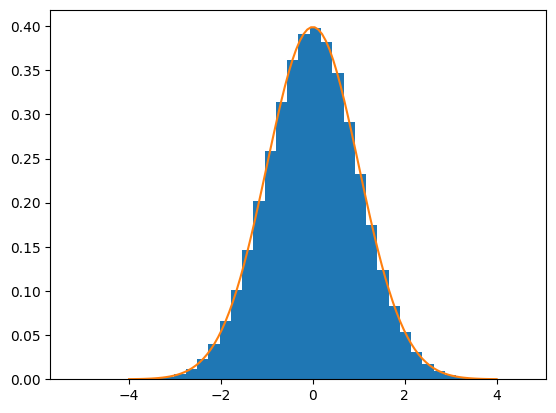

In [73]:
def exp(lam=1):
    u = uniform(0, 1)
    return -np.log(u) / lam


def normal():
    y = exp()
    while uniform(0, 1) > np.exp(-((y - 1) ** 2) / 2):
        y = exp()

    if uniform(0, 1) < 0.5:
        return y
    else:
        return -y


z = [normal() for _ in range(1_000_000)]
x = np.linspace(-4, 4, 100)
plt.hist(z, bins=40, density=True)
plt.plot(x, stats.norm.pdf(x))
plt.show()

26.  Let (X, Y ) be uniformly distributed in a circle of radius 1. Show that if R is the distance from the center of the circle to (X, Y ) then $R^2$ is uniform on (0, 1).

$$
f_{X,Y}=\frac{1}{\pi}I(X^2+Y^2\le 1)
$$
Let $W=R^2=X^2+Y^2$

$$
F_W(w) = P(X^2+Y^2\le w) = \frac{\pi\times w}{\pi} = w, \quad w \in (0,1)
$$

$\implies W=R^2 \sim U(0,1)$

22. Give an algorithm that generates a random variable having density
$$
f(x) = 30(x^2 − 2x^3 + x^4 ), 0 ⩽ x ⩽ 1
$$
Discuss the efficiency of this approach.

$G \sim U(0,1), f'(x)=30(2x-6x^2+4x^3)=60x(2x-1)(x-1)$
$$
\max_x f(x) = f(0.5)=30(\frac{1}{4}-\frac{2}{8}+\frac{1}{16})=\frac{15}{8}
$$

let $c=\frac{15}{8}$

$$
\frac{f(x)}{cg(x)}=\frac{30}{15/8}(x^2 − 2x^3 + x^4 ) = 16 (x^2 − 2x^3 + x^4 )
$$

The Algorith:
1. Generate $U_1,U_2 \overset{iid}{\sim} U(0,1)$
2. If $U_2  \le 16(U_1^2-2U_1^3+U_1^4)$, set $X=U_1$ otherwise return step 1

$P(\text{accept})=\frac{1}{c}=\frac{8}{15}\approx 0.533 $

23. Give an efficient method to generate a random variable X having density

$$
f(x) = \frac{1}{.000336} x(1 − x)^3 , .8 < x < 1

 $$

Note that

$$
\int_{0.8}^1 (1-x)^3 dx = \left[\frac{(1-x)^4}{4} \right]^1_{0.8} = \frac{0.0016}{4} = 0.0004
$$

let $g(x) = \frac{(1-x)^3}{0.0004}, x\in(0.8,1)$ be the proposal density, with CDF:
$$
G(x) = \frac{1}{0.0004}\int_{0.8}^x (1-t)^3 dt = \frac{1}{0.0004}\left[\frac{(1-t)^4}{4} \right]^x_{0.8} = 1-\left(\frac{1-x}{0.2}\right)^4
$$

$$
G(X) = 1-\left(\frac{1-X}{0.2}\right)^4 = U \sim U(0,1) \iff X = 1-0.2(1-U)^{1/4}\overset{d}{=}1-0.2U^{1/4}
$$

$$
c = \max_{x\in(0.8,1)}\frac{f(x)}{g(x)} = \max_{x\in(0.8,1)}\frac{0.0004x}{0.000336} = \frac{0.0004}{0.000336} =\frac{25}{21} \iff \frac{f(x)}{cg(x)} = x
$$


The Algorith:
1. Generate $U_1,U_2 \overset{iid}{\sim} U(0,1)$
2. Set $Y = 1-0.2U_1^{1/4}$
3. If $U_2  \le Y$, set $X=Y$ otherwise return step 1

$P(\text{accept})=\frac{1}{c}=\frac{21}{25}=0.84 $

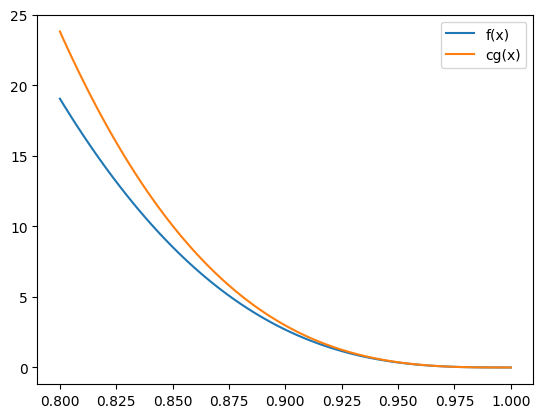

In [94]:
x = np.linspace(0.8,1,100)

plt.plot(x, 1/0.000336 * x*(1-x)**3,label=("f(x)"))
plt.plot(x, 25/21*(1-x)**3/0.0004,label="cg(x)")
plt.legend()
plt.show()

19. Show how to generate a random variable whose distribution function is 

    $$
    F(x) =\frac{1}{2} (x + x^2 ),0 ≤ x ≤ 1
    $$

    using
    
    (a) the inverse transform method;


$$
F(X) = \frac{1}{2}(X+X^2) = \frac{1}{2}(X+\frac{1}{2})^2-\frac{1}{8} = U \sim U(0,1) \iff F^{-1}(U) = (2U+\frac{1}{4})^{1/2}-\frac{1}{2} \sim X
$$

(b) the rejection method;

$f(x)=\frac{1}{2}+x, \max_{x\in(0,1)}f(x)=f(1)=\frac{3}{2}$, let $g(x)=1, c = \frac{3}{2}$

$$
\frac{f(x)}{cg(x)} = \frac{1+2x}{3}
$$

The Algorith:
1. Generate $U_1,U_2 \overset{iid}{\sim} U(0,1)$
2. If $U_2  \le \frac{1+2U_1}{3}$, set $X=U_1$ otherwise return step 1

$P(\text{accept})=\frac{1}{c}=\frac{2}{3}=0.667$

(c) the composition method.

$$f(x)=\frac{1}{2}+x = \begin{cases}
0.5 & f_1(x) = 1 \\
0.5 & f_2(x) = 2x 
\end{cases},\quad x\in(0,1)
$$

hence $f_1(x) \sim U(0,1)$ and $F_2(x) = x^2$, by inverse method $X=\sqrt{U}$

The Algorith:
1. Generate $U, U_1,U_2 \overset{iid}{\sim} U(0,1)$
2. If $U \le 0.5$ set $X=U_1$ else set $X = \sqrt{U_2}$

In this problem, inverse transform method is the best, it only need one Uniform

6.  Let X be an exponential random variable with mean 1. Give an efficient algorithm for simulating a random variable whose distribution is the conditional distribution of X given that X < 0.05. That is, its density function is
$$
f (x) = \frac{e^{-x}}{1-e^{-0.05}} , 0 < x < 0.05

$$
Generate 1000 such variables and use them to estimate $E[X |X < 0.05]$. Then determine the exact value of $E[X |X < 0.05]$.

$$
F(x) = \frac{1}{1-e^{-0.05}}\int_0^x e^{-t} dt = \frac{1-e^{-x}}{1-e^{-0.05}},\quad 0 < x < 0.05
$$

$$
X=F^{-1}(U) = -\ln (1-cU),\quad c = 1-e^{-0.05}, U\sim U(0,1)
$$

In [97]:
u = uniform(0, 1, 1000)
x = -np.log(1 - (1 - np.exp(-0.05)) * u)
x.mean()

np.float64(0.023914850168937286)

$$
E[X|X<0.05] = c\int_0^{0.05} xe^{-x} dx = \left[-cxe^{-x}\right]_0^{0.05} + c\int_0^{0.05}e^{-x} dx =  \left[-c(x+1)e^{-x}\right]_0^{0.05} = c[1-1.05*e^{-0.05}]\approx 0.0248
$$

12. Suppose it is easy to generate random variable from any of the distribution $F_i , i = 1, . . . , n$. How can we generate from the following distributions?

    (a) $F(x)=\prod_{i=1}^nF_i(x)$

$X=\max(X_1,\dots,X_n)$

(b) $F(x)=1-\prod_{i=1}^n[1-F_i(x)]$

$X=\min(X_1,\dots,X_n)$